<a href="https://colab.research.google.com/github/HootlingGondlier/Computational-Physics/blob/main/Lagrangian_and_Plot.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import matplotlib.pyplot as plt
from sympy import *
from sympy.physics.mechanics import *

init_vprinting()

m, g, ell1, ell2, t=symbols('m,g,ell1,ell2,t')

theta1 = dynamicsymbols('theta1')
theta2 = dynamicsymbols('theta2')

x1 = ell1*sin(theta1)
y1 = -ell1*cos(theta1)
x2 = ell1*sin(theta1) + ell2*sin(theta2)
y2 = -ell1*cos(theta1) - ell2*cos(theta2)

x1_dot=diff(x1,t)
y1_dot=diff(y1,t)
x2_dot=diff(x2,t)
y2_dot=diff(y2,t)

theta1_dot=diff(theta1,t)
theta2_dot=diff(theta2,t)
theta1_ddot=diff(theta1_dot,t)
theta2_ddot=diff(theta2_dot,t)

T=0.5*(((x1_dot**2)+(y1_dot**2))+((x2_dot**2)+(y2_dot**2)))
U=m*g*y1 + m*g*y2
L=T-U

eqn1=diff(diff(L,theta1_dot),t)-diff(L,theta1)
eqn2=diff(diff(L,theta2_dot),t)-diff(L,theta2)

sol1=solve(eqn1,theta1_ddot)[0]
sol2=solve(eqn2,theta2_ddot)[0]

Eq(theta1_ddot,sol1)


          ⎛                    2                                         ⎞ 
     -0.5⋅⎝ell₂⋅sin(θ₁ - θ₂)⋅θ₂̇  + ell₂⋅cos(θ₁ - θ₂)⋅θ₂̈ + 2.0⋅g⋅m⋅sin(θ₁)⎠ 
θ₁̈ = ──────────────────────────────────────────────────────────────────────
                                      ell₁                                 

In [ ]:
Eq(theta2_ddot,sol2)

                         2                                     
     ell₁⋅sin(θ₁ - θ₂)⋅θ₁̇  - ell₁⋅cos(θ₁ - θ₂)⋅θ₁̈ - g⋅m⋅sin(θ₂)
θ₂̈ = ──────────────────────────────────────────────────────────
                                ell₂                           

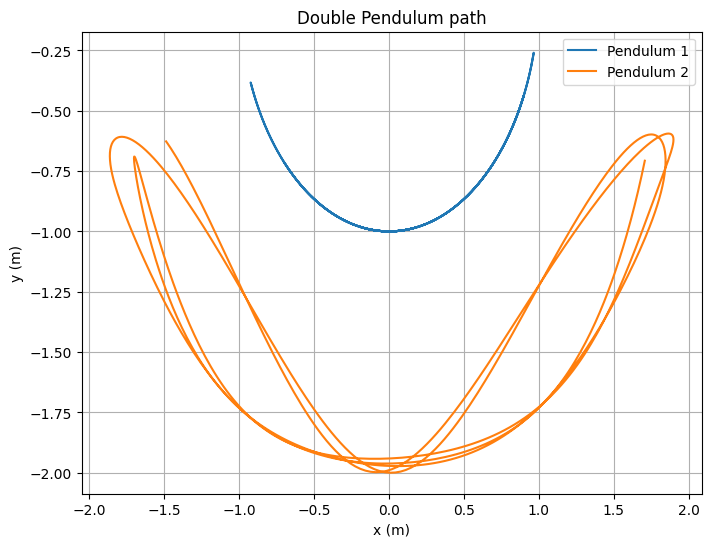

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

def double_pendulum_equations(y, t, ell1, ell2, m, g):
    theta1, theta1_dot, theta2, theta2_dot = y
    theta1_ddot = ( -g * (2 * m) * np.sin(theta1) - m * g * np.sin(theta1 - 2 * theta2) - 2 * np.sin(theta1 - theta2) * m * (theta2_dot ** 2 * ell2 + theta1_dot ** 2 * ell1 * np.cos(theta1 - theta2))) / (ell1 * (2 * m + m - m * np.cos(2 * theta1 - 2 * theta2)))
    theta2_ddot = ( 2 * np.sin(theta1 - theta2) * (theta1_dot ** 2 * ell1 * (m) + g * (m) * np.cos(theta1) + theta2_dot ** 2 * ell2 * m * np.cos(theta1 - theta2))) / (ell2 * (2 * m + m - m * np.cos(2 * theta1 - 2 * theta2)))
    return [theta1_dot, theta1_ddot, theta2_dot, theta2_ddot]


ell1 = 1.0 # Length of the first pendulum
ell2 = 1.0 # Length of the second pendulum
m = 10.0 # Mass of the pendulum
g = 9.81  # Acceleration due to gravity

y0 = [np.pi / 4, 0, np.pi / 2, 0]
t = np.linspace(0, 10, 1000)
sol = odeint(double_pendulum_equations, y0, t, args=(ell1, ell2, m, g))

theta1_sol, theta1_dot_sol, theta2_sol, theta2_dot_sol = sol[:, 0], sol[:, 1], sol[:, 2], sol[:, 3]

x1 = ell1 * np.sin(theta1_sol)
y1 = -ell1 * np.cos(theta1_sol)
x2 = x1 + ell2 * np.sin(theta2_sol)
y2 = y1 - ell2 * np.cos(theta2_sol)

plt.figure(figsize=(8, 6))
plt.plot(x1,y1, label='Pendulum 1')
plt.plot(x2, y2, label='Pendulum 2')
plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.title('Double Pendulum path')
plt.legend()
plt.grid(True)
plt.show()